# HealICON Tutorial

**HealICON** converts atmospheric model output (ICON, ERA5, …) to the [HEALPix](https://healpix.jpl.nasa.gov/) grid and provides a self-contained toolkit for spectral analysis, spatial filtering, vector calculus, and atmospheric tidal analysis.

This notebook walks through the main capabilities using UA-ICON NWP output files bundled in the `examples/` directory.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Test datasets bundled with the examples directory
ICON_FILE      = 'UA-ICON_NWP_atm_DOM01_ML_20250202T000000Z.nc'
ICON_FILE_TEMP = 'UA-ICON_NWP_temp_DOM01_HL_60-110km_202501.nc'

## 1. Interpolation to HEALPix

HealICON re-projects any unstructured or structured grid onto the equal-area HEALPix tessellation.  The target resolution is controlled by `nside` (total pixel count = 12 × nside²).

In [2]:
from healicon.interpolate import interpolate_to_healpix

# Load first time-step to keep this demo fast
ds_icon = xr.open_dataset(ICON_FILE).isel(time=0)

# Interpolate to nside=64  (~55 000 pixels, ~55 km resolution)
ds_hp = interpolate_to_healpix(ds_icon, nside=64)
print(ds_hp)

<xarray.Dataset> Size: 500MB
Dimensions:      (cells: 49152, vertices: 3, height: 180, bnds: 2, height_2: 181)
Coordinates:
  * cells        (cells) int64 393kB 0 1 2 3 4 ... 49147 49148 49149 49150 49151
  * height       (height) float64 1kB 1.0 2.0 3.0 4.0 ... 178.0 179.0 180.0
  * height_2     (height_2) float64 1kB 1.0 2.0 3.0 4.0 ... 179.0 180.0 181.0
    time         datetime64[ns] 8B 2025-02-02
Dimensions without coordinates: vertices, bnds
Data variables: (12/13)
    lon          (cells) float64 393kB 45.0 135.0 225.0 ... 135.0 225.0 315.0
    lat          (cells) float64 393kB 89.27 89.27 89.27 ... -89.27 -89.27
    clon_bnds    (vertices, cells) float64 1MB 0.6882 2.322 ... -2.433 -0.8373
    clat_bnds    (vertices, cells) float64 1MB 1.559 1.559 ... -1.557 -1.558
    height_bnds  (height, bnds) float64 3kB ...
    u            (height, cells) float64 71MB -15.76 -93.88 ... -1.112 -5.18
    ...           ...
    w            (height_2, cells) float64 71MB 0.0 0.0 0.0 ... 0.00

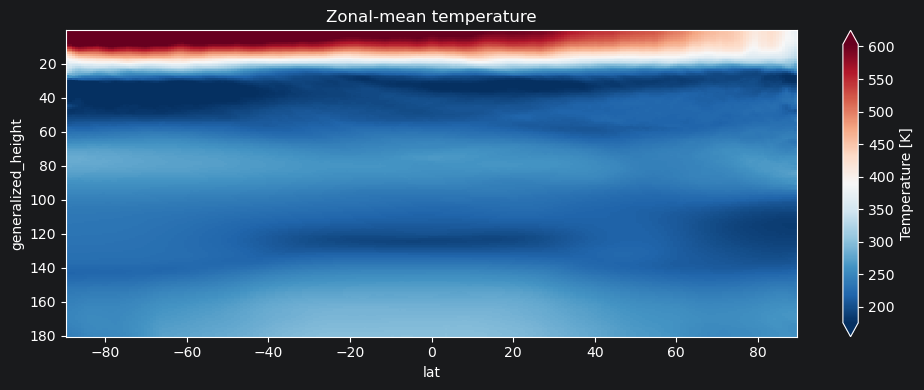

In [3]:
# Zonal mean of temperature as a function of height
from healicon.extract import zonal_mean

ds_zm = zonal_mean(ds_hp[['temp']])
ds_zm['temp'].plot(yincrease=False, figsize=(10, 4), cmap='RdBu_r', robust=True)
plt.title('Zonal-mean temperature')
plt.tight_layout(); plt.show()

## 2. Spectral Analysis and Spatial Filtering

`compute_spectrum` computes the angular power spectrum via spherical harmonic transforms.  `filter_spatial` applies a Gaussian or hard spectral low-pass filter.

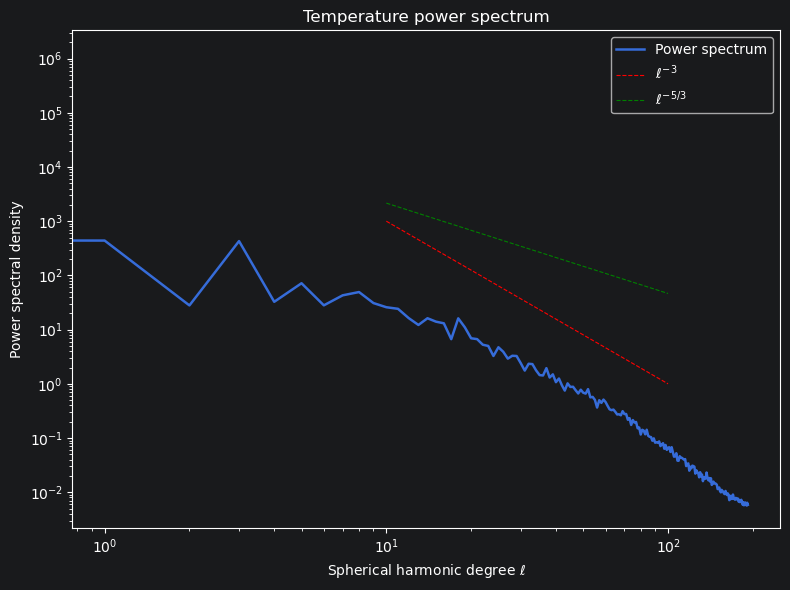

In [4]:
from healicon.analysis import compute_spectrum, filter_spatial, degree_to_wavelength

# Single-level temperature field
ds_lev = ds_hp[['temp']].isel(height=20)

# Angular power spectrum
ds_cl = compute_spectrum(ds_lev, var_name=['temp'], lmax=192).compute()

fig, ax = plt.subplots(figsize=(8, 6))
l = ds_cl['l'].values
ax.loglog(l, ds_cl['temp_cl'].values, lw=1.8, label='Power spectrum')
l_ref = np.array([10, 100])
ax.loglog(l_ref, 1e6 * l_ref**(-3.0), 'r--', lw=0.8, label=r'$\ell^{-3}$')
ax.loglog(l_ref, 1e5 * l_ref**(-5/3.), 'g--', lw=0.8, label=r'$\ell^{-5/3}$')
ax.set_xlabel('Spherical harmonic degree $\ell$')
ax.set_ylabel('Power spectral density')
ax.set_title('Temperature power spectrum')
ax.legend(); plt.tight_layout(); plt.show()

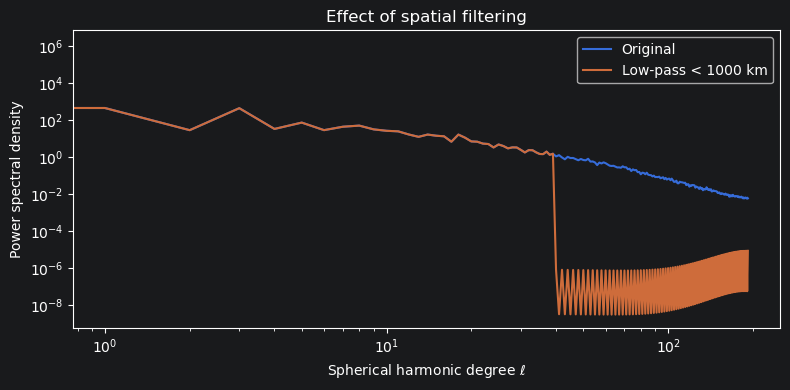

In [5]:
# Hard low-pass filter at 1000 km: retain only large-scale structure
ds_filtered = filter_spatial(ds_lev, wavelength_km=1000).compute()

# Power spectra before and after
ds_cl_filt = compute_spectrum(ds_filtered, var_name=['temp'], lmax=192).compute()

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(l, ds_cl['temp_cl'].values, label='Original')
ax.loglog(ds_cl_filt['l'].values, ds_cl_filt['temp_cl'].values,
          label='Low-pass < 1000 km')
ax.set_xlabel('Spherical harmonic degree $\ell$')
ax.set_ylabel('Power spectral density')
ax.set_title('Effect of spatial filtering')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Vector Calculus: Helmholtz Decomposition

The wind field is split into its **rotational** (non-divergent) and **divergent** (irrotational) parts via a spin-1 spherical harmonic decomposition.  The streamfunction ψ and velocity potential χ are also available.

The **kinetic energy spectrum** of each component reveals the scale-selective breakdown between balanced (rotational) and unbalanced (divergent) flow.

In [6]:
from healicon.analysis import compute_helmholtz

# Wind at a single model level
ds_wind = ds_hp[['u', 'v']].isel(height=50)

ds_helm = compute_helmholtz(ds_wind, u_var='u', v_var='v',
                            include_psi=True, include_chi=True).compute()
print(f'RMS rotational  U: {float(ds_helm["u_rot"].std()):.2f} m/s')
print(f'RMS divergent   U: {float(ds_helm["u_div"].std()):.2f} m/s')

RMS rotational  U: 45.15 m/s
RMS divergent   U: 14.11 m/s


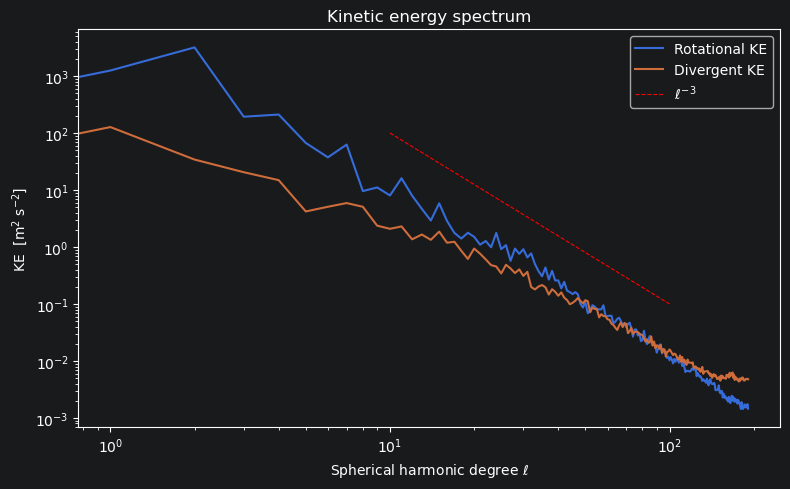

In [7]:
# Kinetic energy spectra of the rotational and divergent components
ds_ke_rot = compute_spectrum(
    ds_helm[['u_rot', 'v_rot']], spectrum_type='kinetic').compute()
ds_ke_div = compute_spectrum(
    ds_helm[['u_div', 'v_div']], spectrum_type='kinetic').compute()

fig, ax = plt.subplots(figsize=(8, 5))
l = ds_ke_rot['l'].values
ke_rot_var = [v for v in ds_ke_rot.data_vars if 'kinetic_energy_cl' in v.lower()]
ke_div_var = [v for v in ds_ke_div.data_vars if 'kinetic_energy_cl' in v.lower()]
if ke_rot_var:
    ax.loglog(l, ds_ke_rot[ke_rot_var[0]].values, label='Rotational KE')
if ke_div_var:
    ax.loglog(l, ds_ke_div[ke_div_var[0]].values, label='Divergent KE')
l_ref = np.array([10, 100])
ax.loglog(l_ref, 1e5 * l_ref**(-3.0), 'r--', lw=0.8, label=r'$\ell^{-3}$')
ax.set_xlabel('Spherical harmonic degree $\ell$')
ax.set_ylabel(r'KE  [m$^2$ s$^{-2}$]')
ax.set_title('Kinetic energy spectrum')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Atmospheric Tidal Analysis

`compute_wavelet_tidal_analysis` extracts tidal signals using a continuous wavelet transform (CWT) combined with either spherical harmonic (`method='sh'`) or ring Fourier (`method='fourier'`) spatial decomposition.

For each tidal mode (period + zonal wavenumber *m*) the output contains:
- `{var}_amp_sym` / `{var}_pha_sym` — **symmetric** (even) component
- `{var}_amp_asy` / `{var}_pha_asy` — **antisymmetric** (odd) component

Dimensions: `(m, period, height, cells)`.

In [8]:
from healicon.analysis import compute_wavelet_tidal_analysis, regrade_resolution

# Temperature dataset: one month at mesosphere/lower-thermosphere heights
ds_temp = xr.open_dataset(ICON_FILE_TEMP)

# Downgrade to nside=32 (~1.8° resolution) to keep the demo fast
ds_temp = regrade_resolution(ds_temp, new_nside=32)

print(ds_temp)
print(f'\nTime span: {ds_temp["time"].values[0]}  →  {ds_temp["time"].values[-1]}')
print(f'Height levels: {ds_temp.sizes.get("height", "?")} '
      f'  ({float(ds_temp["height"].min()):.0f} – {float(ds_temp["height"].max()):.0f} m)')

<xarray.Dataset> Size: 373MB
Dimensions:  (x: 12288, time: 185, height: 41)
Coordinates:
  * x        (x) int64 98kB 0 1 2 3 4 5 ... 12282 12283 12284 12285 12286 12287
  * time     (time) datetime64[ns] 1kB 2025-01-02 ... 2025-01-25
  * height   (height) float64 328B 1.095e+05 1.08e+05 ... 6.131e+04 6.033e+04
Data variables:
    lon      (x) float64 98kB 45.0 46.41 43.59 45.0 ... 315.0 316.4 313.6 315.0
    lat      (x) float64 98kB 1.194 2.388 2.388 3.583 ... -2.388 -2.388 -1.194
    healpix  int32 4B 0
    temp     (time, height, x) float32 373MB 210.1 211.6 224.3 ... 245.5 245.3
Attributes: (12/14)
    CDI:                       Climate Data Interface version 2.2.4 (https://...
    Conventions:               CF-1.6
    source:                    https://gitlab.dkrz.de/icon/icon-nwp.git@ea94c...
    institution:               Max Planck Institute for Meteorology/Deutscher...
    title:                     ICON simulation
    history:                   Fri May 29 12:26:12 2026: cdo s

In [9]:
# Wavelet tidal analysis
# Modes: DW1 (m=+1, 24 h)  SW2 (m=+2, 12 h)  SE2 (m=-2, 12 h)  DE3 (m=-3, 24 h)
ds_tides = compute_wavelet_tidal_analysis(
    ds_temp, var_name='temp',
    periods_hours=[24.0, 12.0],
    m_filters=[1, 2, -2, -3],
    method='fourier',       # faster than 'sh'; equivalent results
    temporal_mean=True,     # time-average amplitude—comparable to least-squares
    dj=0.2,                 # coarser CWT scale spacing → faster
).compute()

print(ds_tides)

<xarray.Dataset> Size: 129MB
Dimensions:       (x: 12288, height: 41, period: 2, m: 4)
Coordinates:
  * x             (x) int64 98kB 0 1 2 3 4 5 ... 12283 12284 12285 12286 12287
    lon           (x) float64 98kB 45.0 46.41 43.59 45.0 ... 316.4 313.6 315.0
    lat           (x) float64 98kB 1.194 2.388 2.388 ... -2.388 -2.388 -1.194
  * height        (height) float64 328B 1.095e+05 1.08e+05 ... 6.033e+04
  * period        (period) timedelta64[s] 16B 1 days 12:00:00
  * m             (m) int64 32B -3 -2 1 2
Data variables:
    temp_pha_sym  (m, period, height, x) float64 32MB 0.8625 0.8555 ... 0.9944
    temp_amp_sym  (m, period, height, x) float64 32MB 5.695 5.533 ... 0.9252
    temp_amp_asy  (m, period, height, x) float64 32MB 0.1507 0.236 ... 0.04911
    temp_pha_asy  (m, period, height, x) float64 32MB -1.628 -2.014 ... 0.7637
    healpix       int32 4B 0
Attributes: (12/16)
    CDI:                            Climate Data Interface version 2.2.4 (htt...
    Conventions:           

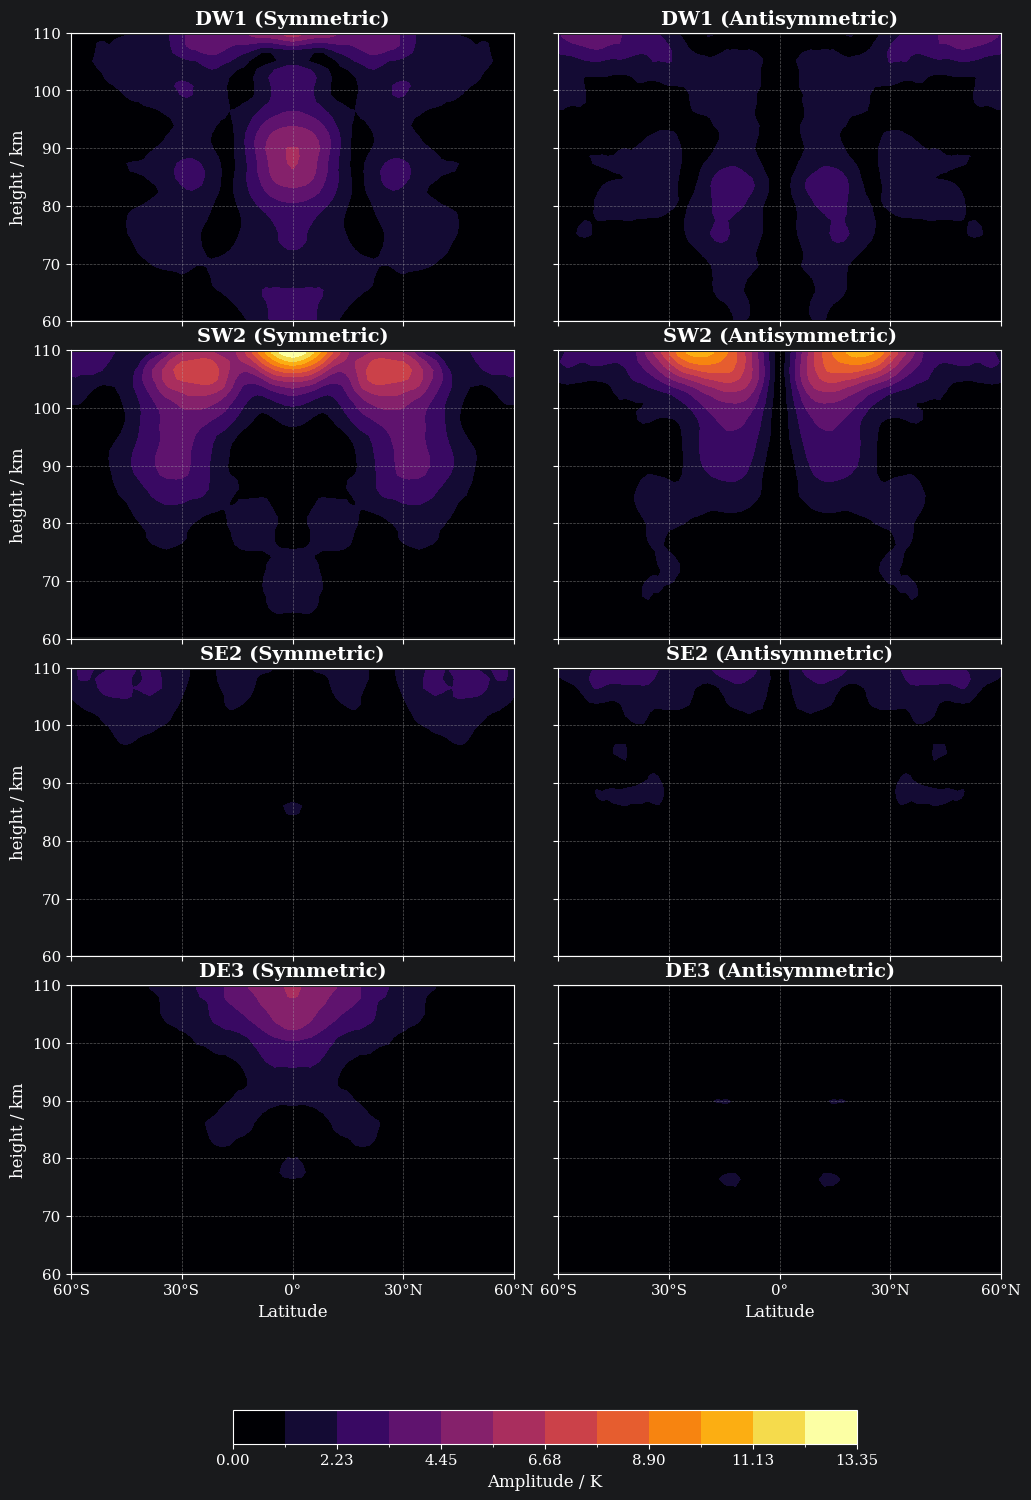

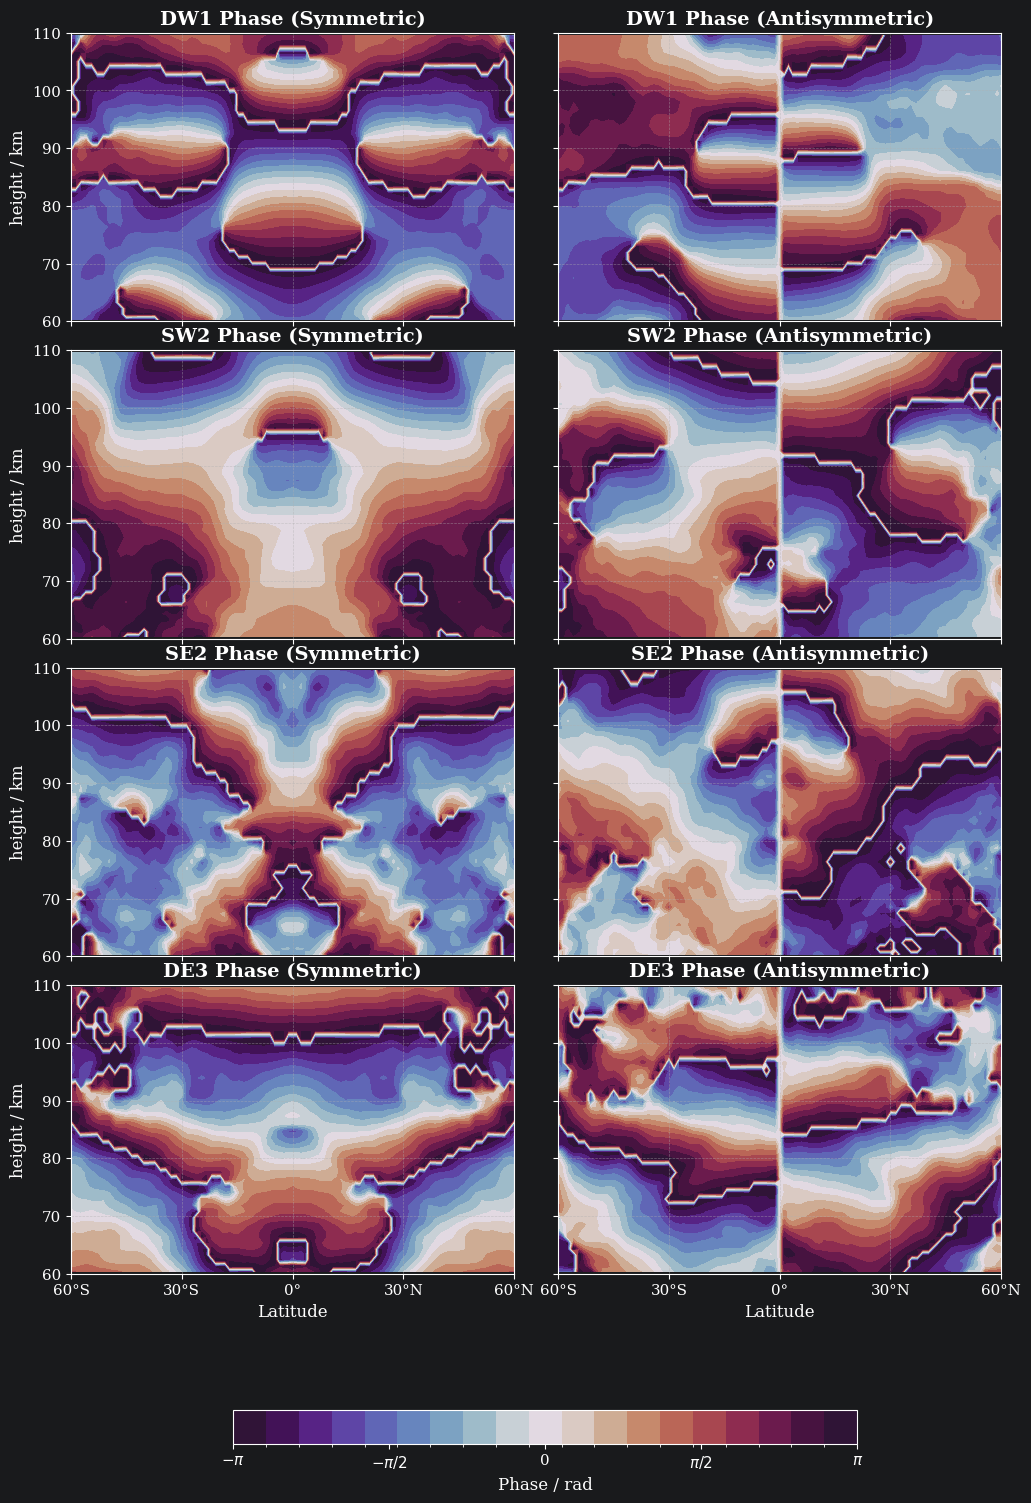

Saved: tutorial_tides_amplitude.png  tutorial_tides_phase.png


In [10]:
from healicon.visualize import plot_tides
from healicon.extract import zonal_mean

# Zonal mean with circular averaging for phase
amp_vars = [v for v in ds_tides.data_vars if '_amp_' in v]
pha_vars = [v for v in ds_tides.data_vars if '_pha_' in v]
parts = {v: ds_tides[v] for v in amp_vars}
for v in pha_vars:
    v_amp = v.replace('_pha_', '_amp_')
    w = ds_tides[v_amp] if v_amp in ds_tides else xr.ones_like(ds_tides[v])
    parts[v] = np.arctan2(
        (w * np.sin(ds_tides[v])),
        (w * np.cos(ds_tides[v])),
    )
ds_zm = zonal_mean(xr.Dataset(parts, attrs=ds_tides.attrs))

# plot_tides auto-detects sym/asy vs total mode
plot_tides(ds_zm, out_dir='.', prefix='tutorial_tides')
print('Saved: tutorial_tides_amplitude.png  tutorial_tides_phase.png')

# Show the amplitude plot inline
from IPython.display import Image
Image('tutorial_tides_amplitude.png')

## 5. Total Tidal Field  (`decompose_sym_asy=False`)

Passing `decompose_sym_asy=False` skips the equatorial symmetric/antisymmetric decomposition.  The output uses `_amp_total` and `_pha_total` variables — useful when equatorial symmetry is not required or to reduce memory by ~50 %.

['temp_amp_total', 'temp_pha_total', 'healpix']
<xarray.Dataset> Size: 33MB
Dimensions:         (x: 12288, height: 41, period: 2, m: 2)
Coordinates:
  * x               (x) int64 98kB 0 1 2 3 4 5 ... 12283 12284 12285 12286 12287
    lon             (x) float64 98kB 45.0 46.41 43.59 45.0 ... 316.4 313.6 315.0
    lat             (x) float64 98kB 1.194 2.388 2.388 ... -2.388 -2.388 -1.194
  * height          (height) float64 328B 1.095e+05 1.08e+05 ... 6.033e+04
  * period          (period) timedelta64[s] 16B 1 days 12:00:00
  * m               (m) int64 16B 1 2
Data variables:
    temp_amp_total  (m, period, height, x) float64 16MB 5.931 5.804 ... 0.9731
    temp_pha_total  (m, period, height, x) float64 16MB 2.295 2.217 ... 0.9829
    healpix         int32 4B 0
Attributes: (12/16)
    CDI:                            Climate Data Interface version 2.2.4 (htt...
    Conventions:                    CF-1.6
    source:                         https://gitlab.dkrz.de/icon/icon-nwp.git@...
  

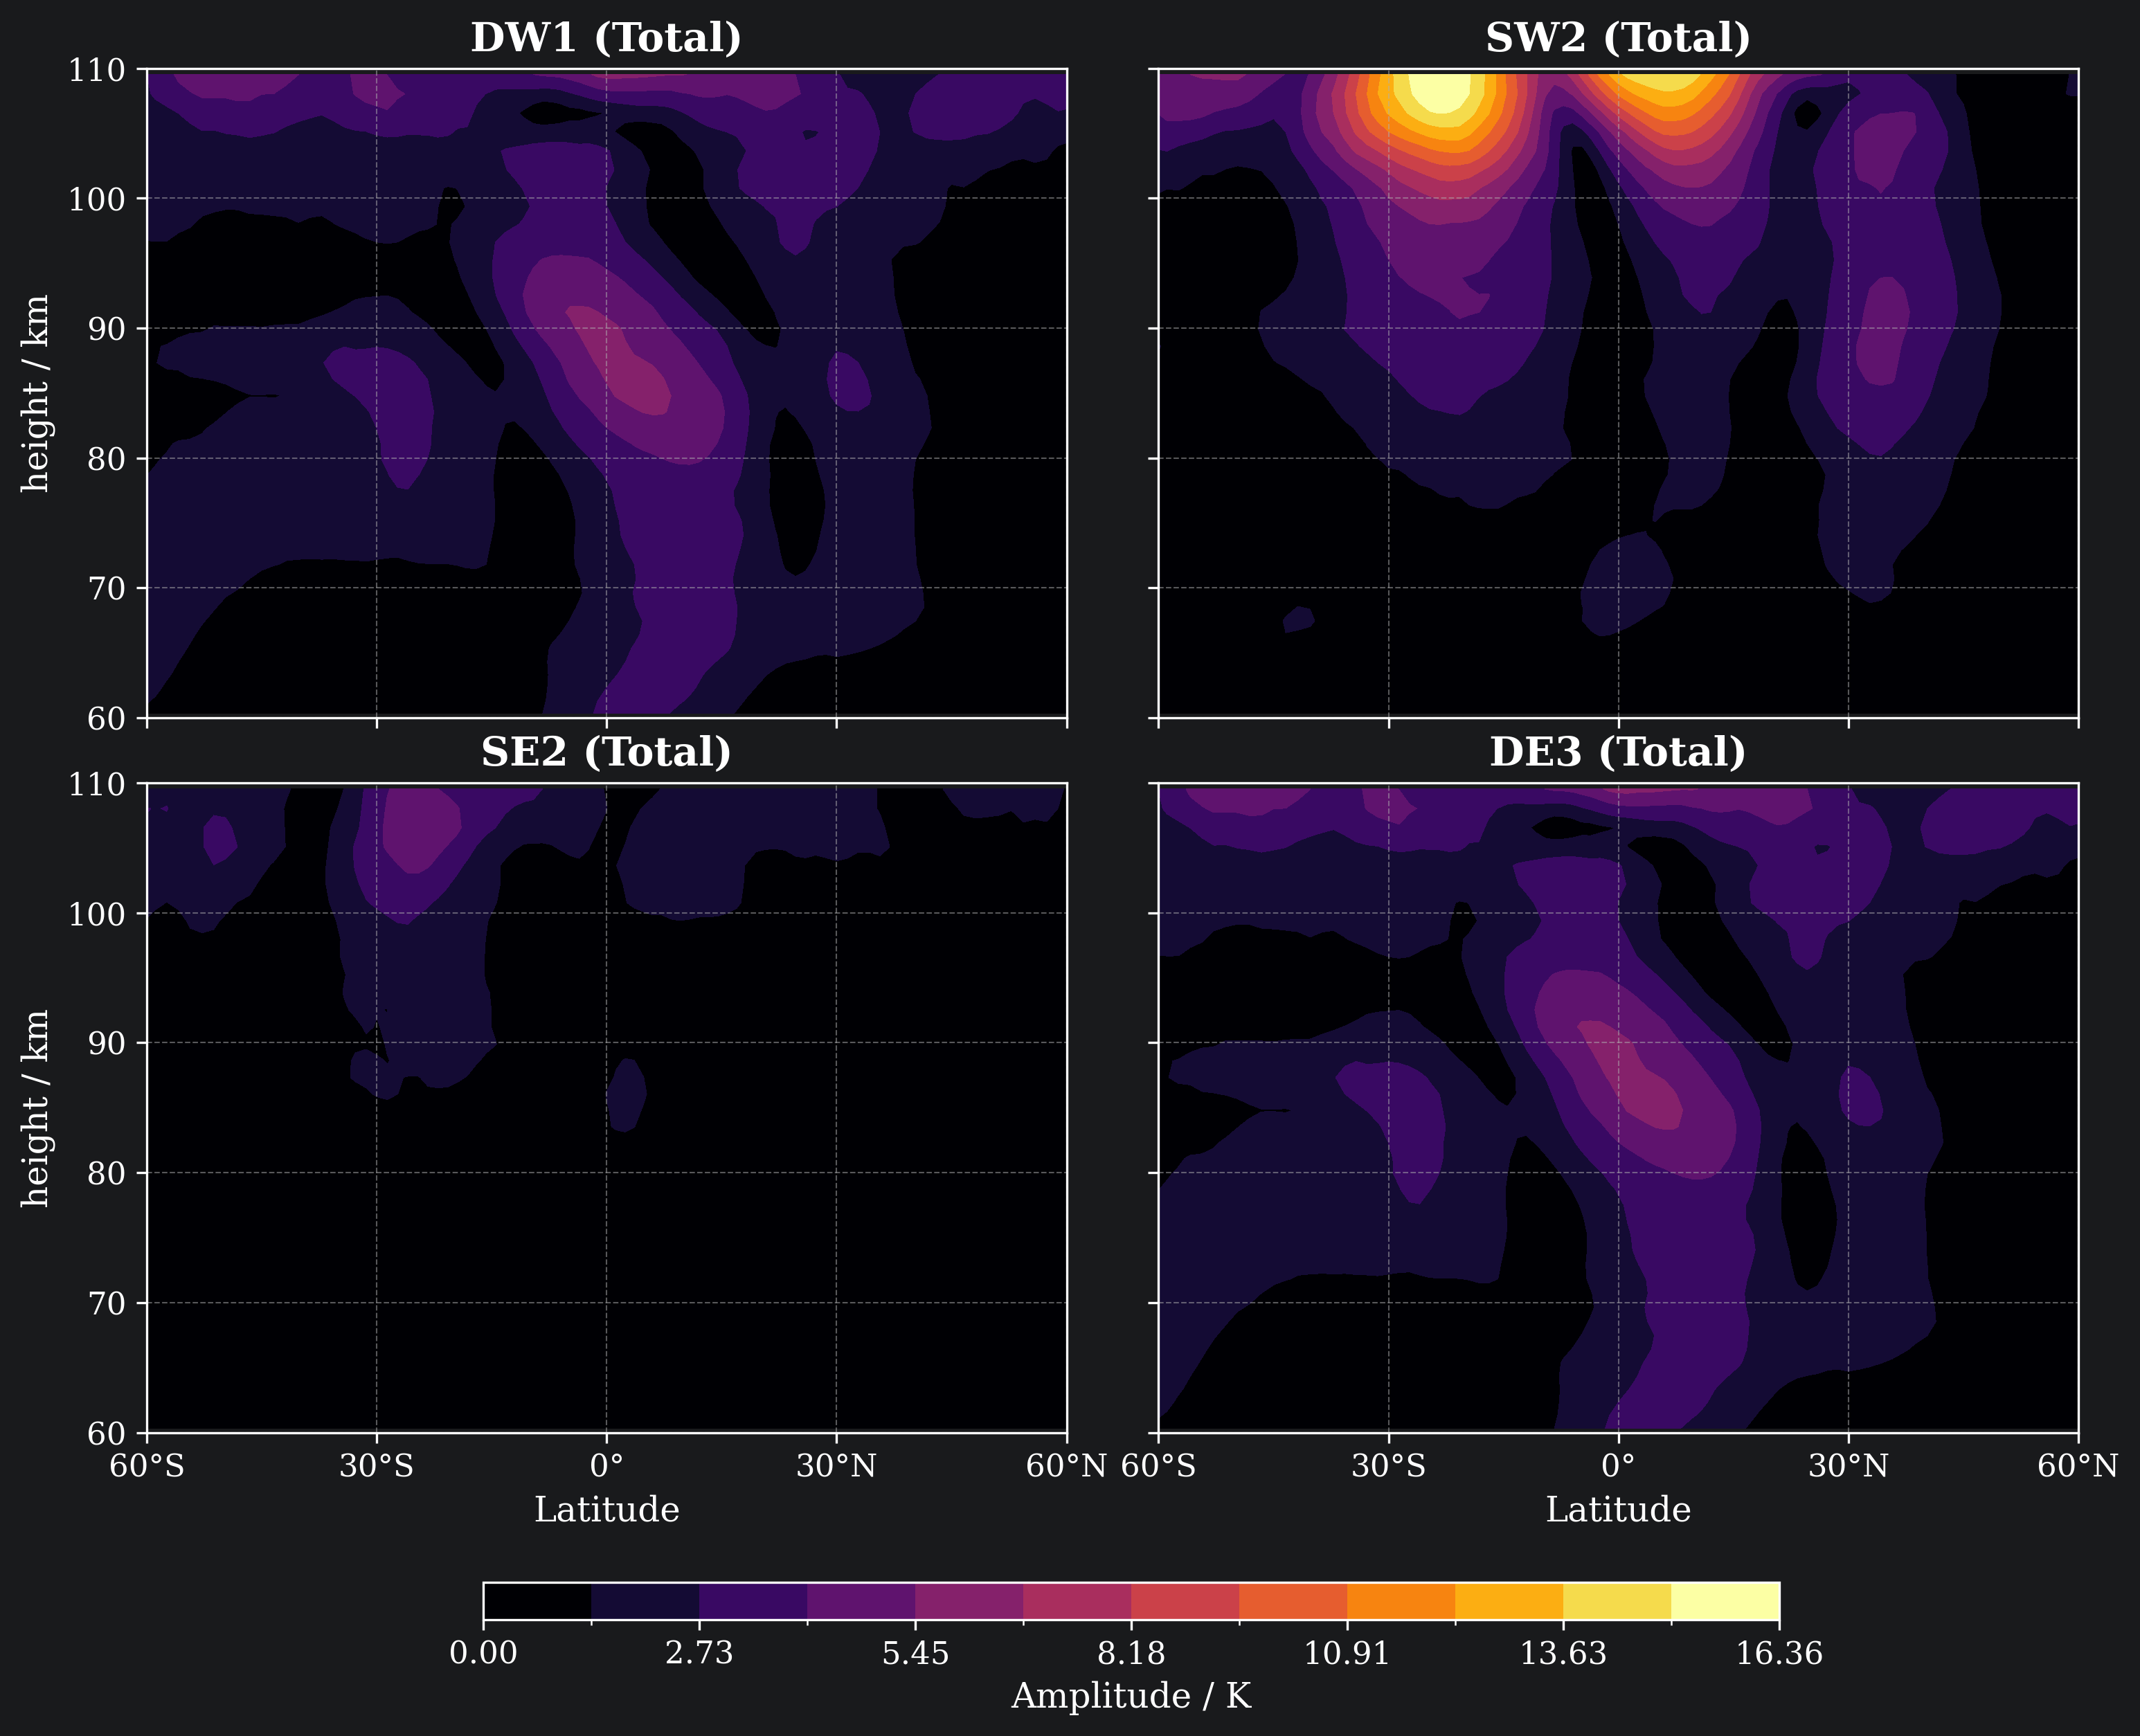

In [14]:
ds_tides_total = compute_wavelet_tidal_analysis(
    ds_temp, var_name='temp',
    periods_hours=[24.0, 12.0],
    m_filters=[1, 2],           # DW1 + SW2 for brevity
    method='fourier',
    temporal_mean=True,
    dj=0.2,
    decompose_sym_asy=False,    # ← skip equatorial split
).compute()

print([v for v in ds_tides_total.data_vars])
print(ds_tides_total)

# plot_tides detects _amp_total automatically
ds_zm_total = zonal_mean(ds_tides_total)
plot_tides(ds_zm_total, out_dir='.', prefix='tutorial_tides_total')

Image('tutorial_tides_total_amplitude.png')